# AIC144 Relative Dose Plot: MC vs EBT3 vs MBO

This notebook loads AIC144 profiles, aligns them horizontally using the **distal 90% falloff point** while keeping **MC as the reference**, and rescales every profile so that its maximum equals **1.0**.

Color convention:
- **MC** in **black**
- **EBT3** in **red**
- **MBO** in **green**

The figure uses larger fonts for presentation and publication readability.

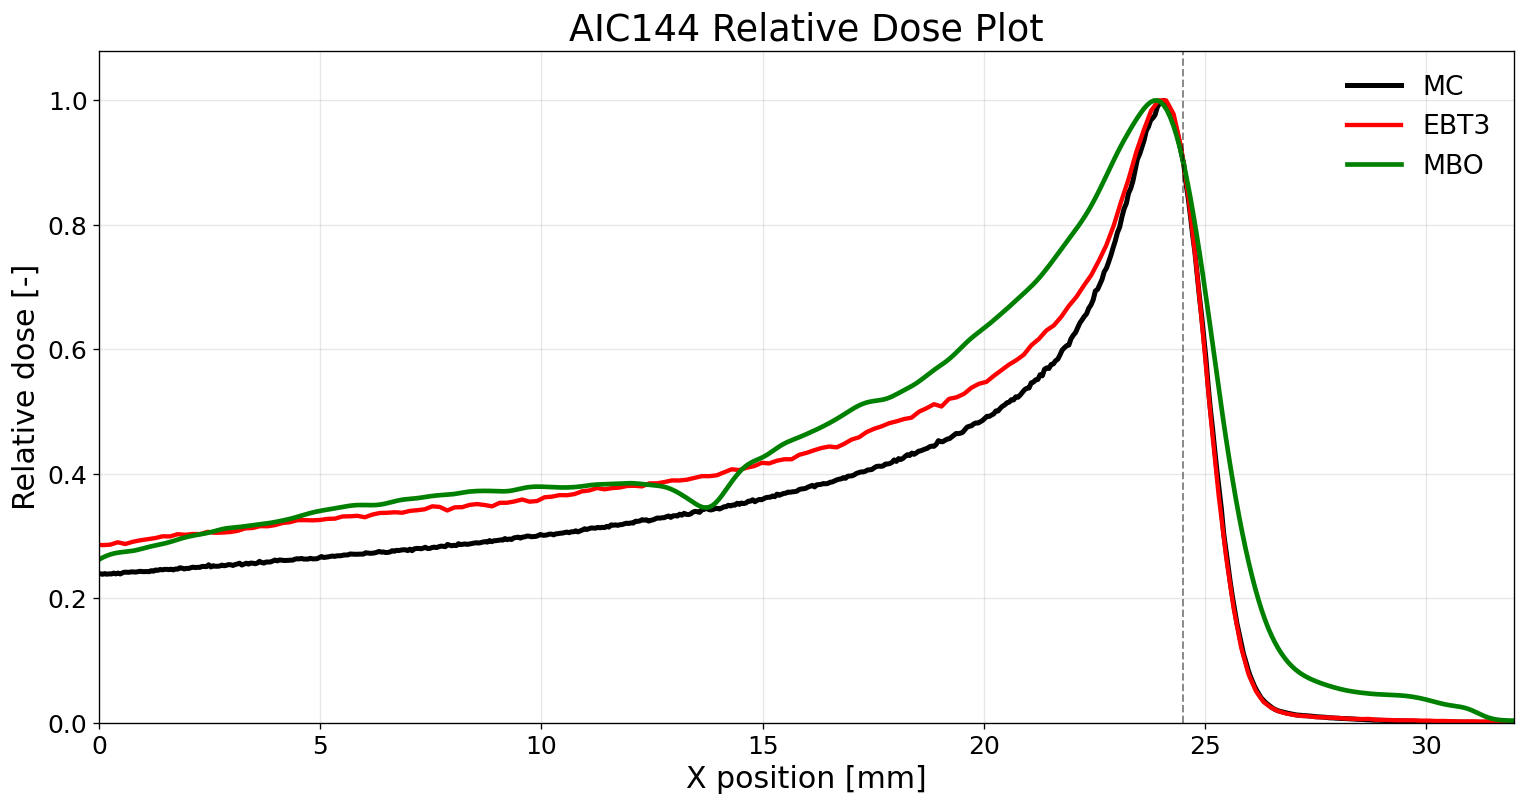

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Resolve repository root from current working directory.
repo_root = Path.cwd()
if not (repo_root / "notebooks" / "pub_something_2026").exists():
    for parent in repo_root.parents:
        if (parent / "notebooks" / "pub_something_2026").exists():
            repo_root = parent
            break

data_root = repo_root / "notebooks" / "pub_something_2026"

mc_file = data_root / "mc" / "mc_aic144_big.csv"
ebt_file = data_root / "ebt_foils" / "ebt_profile_aic144.csv"
mbo_file = data_root / "mbo_foils" / "mbo_profile_aic144.csv"

for f in (mc_file, ebt_file, mbo_file):
    if not f.exists():
        raise FileNotFoundError(f"Missing input file: {f}")

mc = pd.read_csv(mc_file).rename(columns={"depth": "x_mm", "dose": "dose_Gy"})
ebt = pd.read_csv(ebt_file)
mbo = pd.read_csv(mbo_file)

def prepare_profile(df):
    profile = df[["x_mm", "dose_Gy"]].copy().sort_values("x_mm").reset_index(drop=True)
    profile["relative_dose"] = profile["dose_Gy"] / profile["dose_Gy"].max()
    return profile

def distal_falloff_point(profile, level=0.9):
    x = profile["x_mm"].to_numpy()
    y = profile["relative_dose"].to_numpy()

    peak_idx = y.argmax()
    for idx in range(peak_idx + 1, len(y)):
        if y[idx] <= level:
            x0, x1 = x[idx - 1], x[idx]
            y0, y1 = y[idx - 1], y[idx]
            if y1 == y0:
                return x1
            fraction = (level - y0) / (y1 - y0)
            return x0 + fraction * (x1 - x0)

    raise ValueError(f"Could not find distal {level:.0%} falloff point.")

mc = prepare_profile(mc)
ebt = prepare_profile(ebt)
mbo = prepare_profile(mbo)

mc_range_90 = distal_falloff_point(mc, level=0.9)
ebt_range_90 = distal_falloff_point(ebt, level=0.9)
mbo_range_90 = distal_falloff_point(mbo, level=0.9)

ebt_shift = mc_range_90 - ebt_range_90
mbo_shift = mc_range_90 - mbo_range_90

ebt["x_aligned_mm"] = ebt["x_mm"] + ebt_shift
mbo["x_aligned_mm"] = mbo["x_mm"] + mbo_shift
mc["x_aligned_mm"] = mc["x_mm"]

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 22,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 16,
})

fig, ax = plt.subplots(figsize=(13, 7), dpi=120)

ax.plot(mc["x_aligned_mm"], mc["relative_dose"], color="black", linewidth=3.0, label="MC")
ax.plot(ebt["x_aligned_mm"], ebt["relative_dose"], color="red", linewidth=2.6, label="EBT3")
ax.plot(mbo["x_aligned_mm"], mbo["relative_dose"], color="green", linewidth=2.8, label="MBO")

ax.axvline(mc_range_90, color="black", linestyle="--", linewidth=1.2, alpha=0.45)

ax.set_title("AIC144 Relative Dose Plot")
ax.set_xlabel("X position [mm]")
ax.set_ylabel("Relative dose [-]")
ax.set_xlim(0, 32)
ax.set_ylim(0, 1.08)
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()